# EDA – Certifications SNEP

**Objectif** : Explorer le dataset des certifications SNEP en vue de construire un graphe de co-artistes et d'appliquer l'algorithme de Louvain pour la détection de communautés musicales.  
**Source** : [snepmusique.com/les-certifications](https://snepmusique.com/les-certifications/)  
**Fichier** : `data/snep_certifications.csv`

## 0. Imports

In [90]:
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

DATA_PATH = Path('../data/snep_certifications.csv')

## 1. Chargement et aperçu

In [91]:
df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8-sig', parse_dates=['Date de sortie', 'Date de constat'], dayfirst=True)
print(f'Shape : {df.shape}')
df.head(10)

Shape : (8384, 8)


,Interprete,Titre,Editeur / Distributeur,Categorie,Certification,Date de sortie,Date de constat,Duree obtention
0,UZI,AKRAPOVITCH 5,ARGENTIC MUSIC / CAPITOL MUSIC FRANCE / UNIVER...,Singles,Or,2020-01-23,2026-04-23,6 ans 4 mois
1,RIM'K,MONSTER,VIRGIN RECORDS FRANCE / UNIVERSAL MUSIC FRANCE,Singles,Or,2016-01-15,2026-04-23,10 ans 5 mois
2,"ALAN WALKER, SABRINA CARPENTER & FARRUKO",ON MY WAY,KREATELL MUSIC / SONY MUSIC ENTERTAINMENT,Singles,Or,2019-03-15,2026-04-23,7 ans 2 mois
3,JOK'AIR,NUIT ET JOUR,PLAY TWO / BELIEVE,Singles,Or,2020-03-20,2026-04-23,6 ans 2 mois
4,LACRIM,L'IMMORTALE,PLATA O PLOMO RECORDS / CAPITOL MUSIC FRANCE /...,Singles,Or,2021-09-22,2026-04-23,4 ans 7 mois
5,NIRO,JAMAIS DE NOUS,AMBITION MUSIC / SONY MUSIC ENTERTAINMENT,Singles,Or,2023-02-10,2026-04-23,3 ans 2 mois
6,TIF,DEMAIN C'EST B3ID,HOUMA SWEET HOUMA / ADA MUSIC FRANCE / WARNER ...,Singles,Or,2023-03-10,2026-04-23,3 ans 2 mois
7,"ALOK, MONDELLO’ G, CERES & TRIBBS",LET'S GET FKD UP,COLUMBIA / B1 RECORDINGS / SONY MUSIC ENTERTAI...,Singles,Or,2023-11-17,2026-04-23,2 ans 5 mois
8,YOUSSOUPHA,DIEU EST GRANDE,99 REVOLUTION / ALLPOINTS / BELIEVE,Singles,Or,2025-01-10,2026-04-23,1 an 3 mois
9,WERENOI,INDUSTRY PLANT,PLR MUSIC / PGP RECORDS / ALLPOINTS / BELIEVE,Singles,Or,2025-04-11,2026-04-23,1 an


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8384 entries, 0 to 8383
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Interprete              8384 non-null   object        
 1   Titre                   8372 non-null   object        
 2   Editeur / Distributeur  8379 non-null   object        
 3   Categorie               8384 non-null   object        
 4   Certification           8384 non-null   object        
 5   Date de sortie          8312 non-null   datetime64[ns]
 6   Date de constat         8380 non-null   datetime64[ns]
 7   Duree obtention         7853 non-null   object        
dtypes: datetime64[ns](2), object(6)
memory usage: 524.1+ KB


In [93]:
df.describe(include='all')

,Interprete,Titre,Editeur / Distributeur,Categorie,Certification,Date de sortie,Date de constat,Duree obtention
count,8384,8372,8379,8384,8384,8312,8380,7853
unique,3042,7288,2728,4,11,NaN,NaN,282
top,COMPILATION,BEST OF,SONY MUSIC,Singles,Or,NaN,NaN,1 mois
freq,387,42,247,3962,4757,NaN,NaN,509
mean,NaN,NaN,NaN,NaN,NaN,2009-04-30 13:55:02.021174016,2011-12-26 02:10:15.178997504,NaN
min,NaN,NaN,NaN,NaN,NaN,1952-01-01 00:00:00,1976-01-01 00:00:00,NaN
25%,NaN,NaN,NaN,NaN,NaN,2000-03-05 18:00:00,2001-10-17 00:00:00,NaN
50%,NaN,NaN,NaN,NaN,NaN,2015-01-10 12:00:00,2016-10-07 00:00:00,NaN
75%,NaN,NaN,NaN,NaN,NaN,2019-04-26 00:00:00,2023-03-23 00:00:00,NaN
max,NaN,NaN,NaN,NaN,NaN,2026-03-12 00:00:00,2026-04-23 00:00:00,NaN


## 2. Valeurs manquantes

In [94]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Manquants': missing, '% manquants': missing_pct})

,Manquants,% manquants
Duree obtention,531,6.33
Date de sortie,72,0.86
Titre,12,0.14
Editeur / Distributeur,5,0.06
Date de constat,4,0.05
Interprete,0,0.00
Categorie,0,0.00
Certification,0,0.00


In [95]:
# Calcul de la durée d'obtention en jours depuis les dates
# → remplace la colonne textuelle 'Duree obtention' (inutile désormais)
df['jours_obtention'] = (df['Date de constat'] - df['Date de sortie']).dt.days
df = df.drop(columns=['Duree obtention'])

# Nettoyage : suppression des lignes avec valeurs manquantes
# → 'Titre' ignoré (peu important), 'Date de sortie'/'Date de constat' couvertes par 'jours_obtention'
cols_requises = [c for c in df.columns if c not in ('Titre', 'Date de sortie', 'Date de constat')]
avant = len(df)
df = df.dropna(subset=cols_requises).reset_index(drop=True)

print(f'Lignes avant nettoyage : {avant}')
print(f'Lignes après nettoyage : {len(df)}  ({avant - len(df)} supprimées, {(avant - len(df)) / avant:.1%})')
print(f'\nValeurs manquantes restantes :')
manquants = df.isnull().sum()
print(manquants[manquants > 0].rename('NaN restants') if manquants.any() else 'Aucune valeur manquante')


Lignes avant nettoyage : 8384
Lignes après nettoyage : 8303  (81 supprimées, 1.0%)

Valeurs manquantes restantes :
Titre    12
Name: NaN restants, dtype: int64


## 3. Distribution des certifications

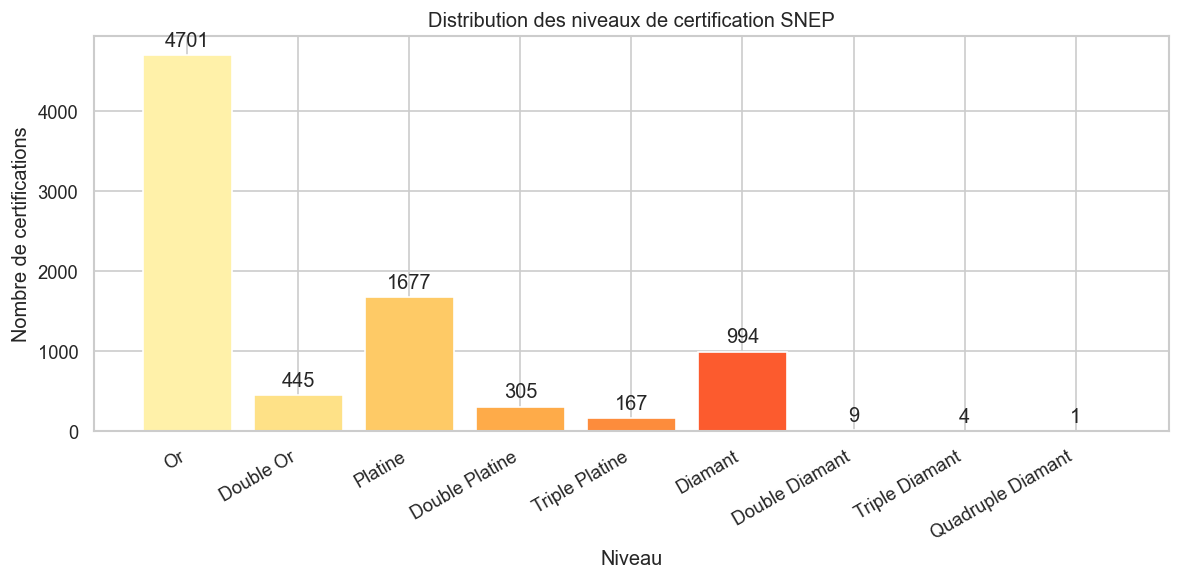

In [96]:
# Normalisation des niveaux de certification (casse)
df['Certification_norm'] = df['Certification'].str.strip().str.title()

cert_order = ['Or', 'Double Or', 'Platine', 'Double Platine', 'Triple Platine',
              'Diamant', 'Double Diamant', 'Triple Diamant', 'Quadruple Diamant']
cert_counts = df['Certification_norm'].value_counts().reindex(cert_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cert_counts.index, cert_counts.values,
              color=sns.color_palette('YlOrRd', len(cert_counts)))
ax.bar_label(bars, padding=3)
ax.set_title('Distribution des niveaux de certification SNEP')
ax.set_xlabel('Niveau')
ax.set_ylabel('Nombre de certifications')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../plots/certif_distribution.png')
plt.show()

## 4. Distribution des catégories

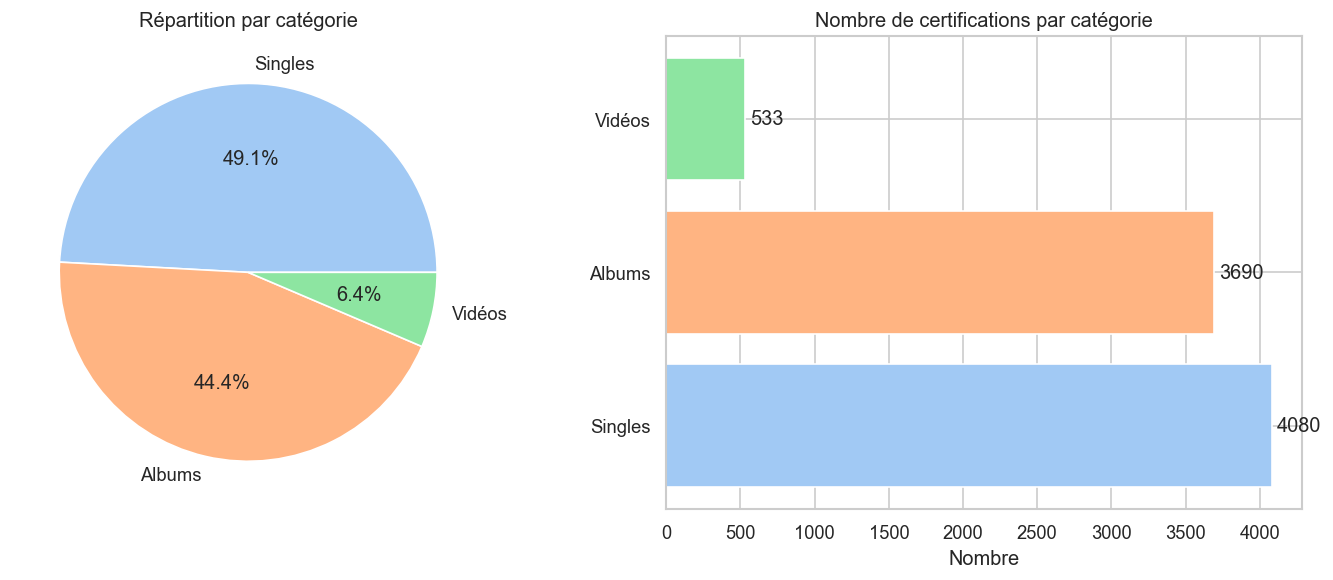

In [97]:
# Normalisation : 'Single' -> 'Singles'
df['Categorie_norm'] = df['Categorie'].str.strip().replace('Single', 'Singles')

cat_counts = df['Categorie_norm'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'))
axes[0].set_title('Répartition par catégorie')

bars = axes[1].barh(cat_counts.index, cat_counts.values,
                     color=sns.color_palette('pastel'))
axes[1].bar_label(bars, padding=3)
axes[1].set_title('Nombre de certifications par catégorie')
axes[1].set_xlabel('Nombre')

plt.tight_layout()
plt.savefig('../plots/categorie_distribution.png')
plt.show()

## 5. Top artistes

/var/folders/84/zqd10b2n6jd17bm5tfw84l680000gn/T/ipykernel_2434/2703459778.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, ax=ax,


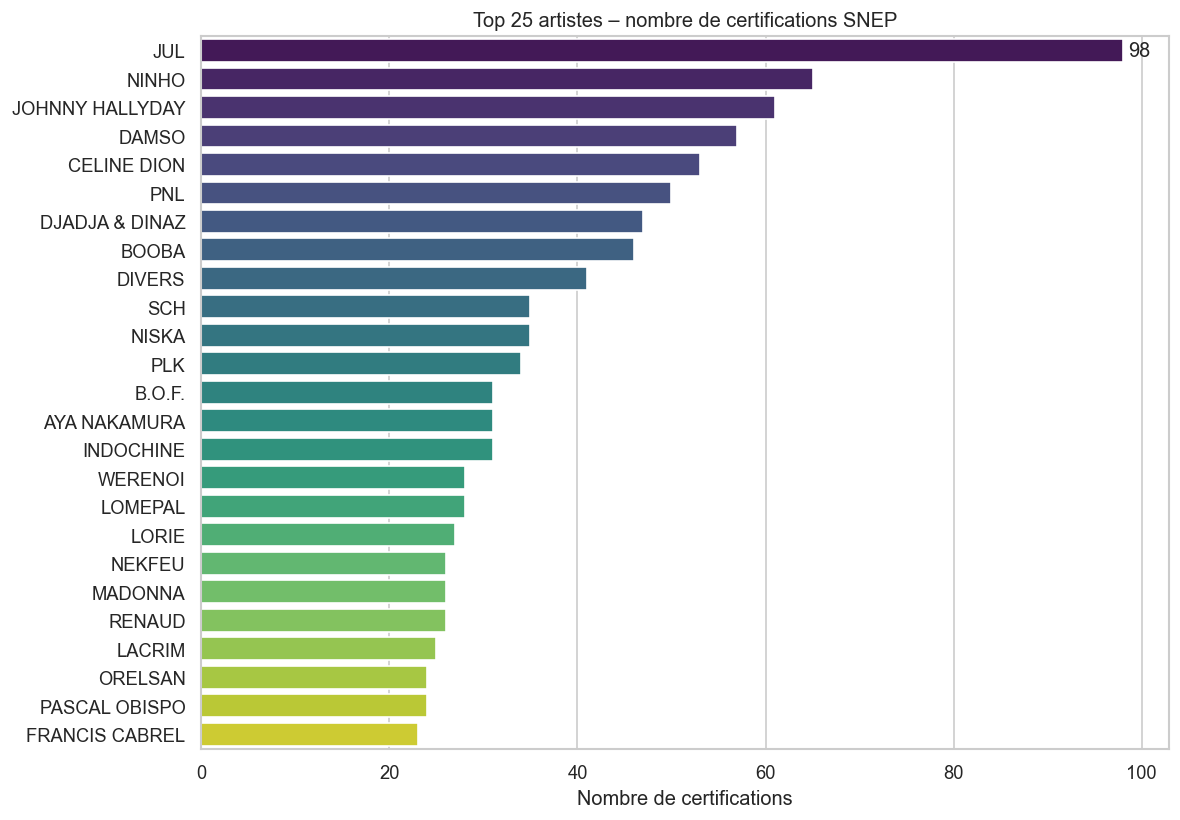

In [98]:
# Exclure les artistes génériques
EXCLUDE = {'COMPILATION', 'MULTI INTERPRETES'}
top_artists = (
    df[~df['Interprete'].isin(EXCLUDE)]['Interprete']
    .value_counts()
    .head(25)
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_artists.values, y=top_artists.index, ax=ax,
            palette='viridis')
ax.bar_label(ax.containers[0], padding=3)
ax.set_title('Top 25 artistes – nombre de certifications SNEP')
ax.set_xlabel('Nombre de certifications')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../plots/top_artists.png')
plt.show()

In [99]:
# Top artistes par niveau de certification (diamant uniquement)
diamant_artists = (
    df[df['Certification_norm'].str.contains('Diamant', na=False)]
    .groupby('Interprete')
    .size()
    .sort_values(ascending=False)
    .head(15)
)
print('Top 15 artistes avec le plus de certifications Diamant :')
print(diamant_artists.to_string())

Top 15 artistes avec le plus de certifications Diamant :
Interprete
PNL                23
DAMSO              19
JUL                17
NINHO              16
NISKA              11
NEKFEU             11
JOHNNY HALLYDAY    10
ORELSAN            10
PLK                10
BOOBA              10
AYA NAKAMURA        9
LOMEPAL             8
DJADJA & DINAZ      7
WERENOI             7
IMAGINE DRAGONS     7


## 6. Analyse temporelle

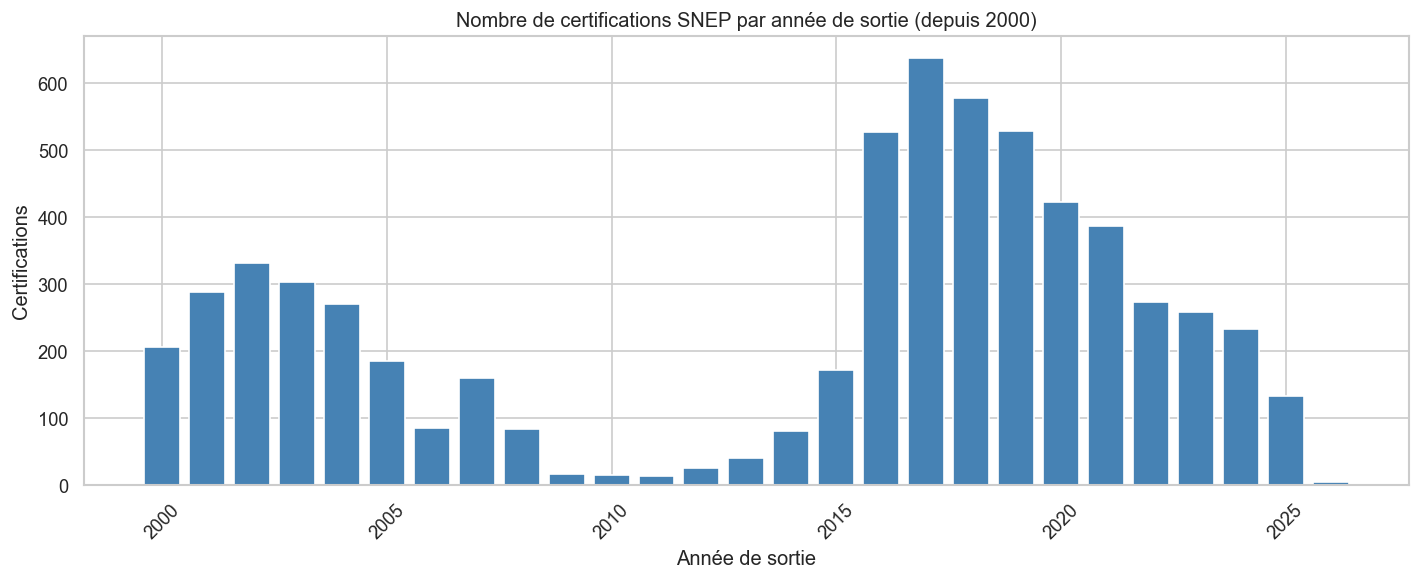

In [100]:
df_dated = df.dropna(subset=['Date de sortie']).copy()
df_dated['Annee sortie'] = df_dated['Date de sortie'].dt.year

# Certifications par année de sortie (depuis 2000)
yearly = df_dated[df_dated['Annee sortie'] >= 2000].groupby('Annee sortie').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(yearly.index, yearly.values, color='steelblue')
ax.set_title('Nombre de certifications SNEP par année de sortie (depuis 2000)')
ax.set_xlabel('Année de sortie')
ax.set_ylabel('Certifications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../plots/certifs_by_year.png')
plt.show()

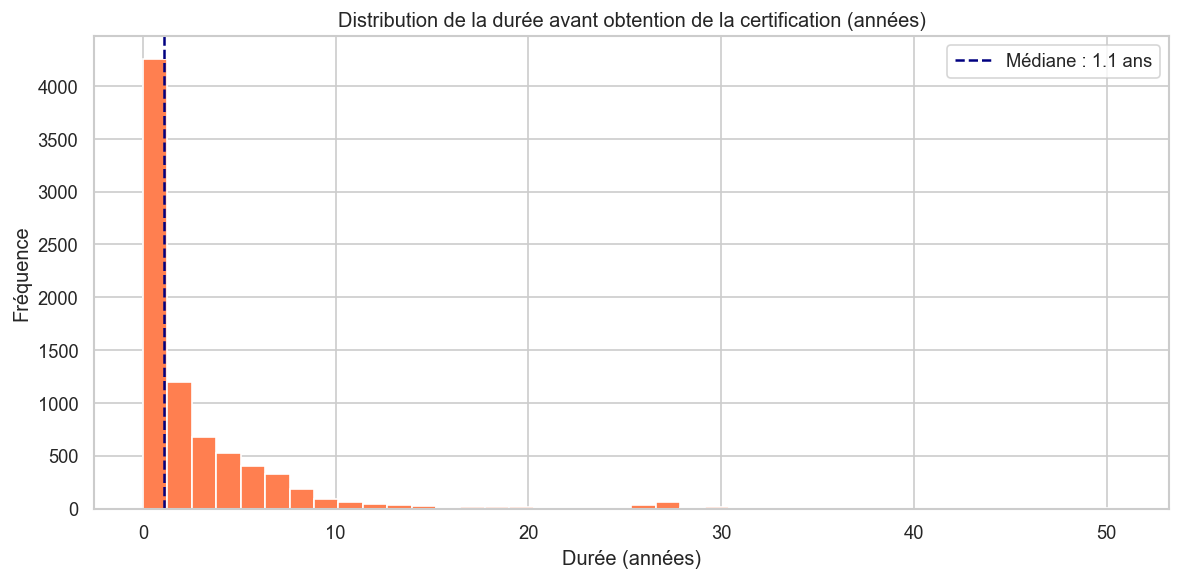

count     8023.000000
mean      1028.449582
std       1633.658326
min          1.000000
25%        150.000000
50%        407.000000
75%       1300.000000
max      18501.000000
Name: jours_obtention, dtype: float64


In [101]:
# Durée avant obtention de la certification (jours_obtention déjà calculé au nettoyage)
df_time = df[df['jours_obtention'] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_time['jours_obtention'] / 365, bins=40, color='coral', edgecolor='white')
ax.axvline(df_time['jours_obtention'].median() / 365, color='navy',
           linestyle='--', label=f"Médiane : {df_time['jours_obtention'].median()/365:.1f} ans")
ax.set_title('Distribution de la durée avant obtention de la certification (années)')
ax.set_xlabel('Durée (années)')
ax.set_ylabel('Fréquence')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/duree_obtention.png')
plt.show()

print(df_time['jours_obtention'].describe())


## 7. Analyse des labels / distributeurs

/var/folders/84/zqd10b2n6jd17bm5tfw84l680000gn/T/ipykernel_2434/1913720089.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_labels.values, y=top_labels.index, ax=ax, palette='crest')


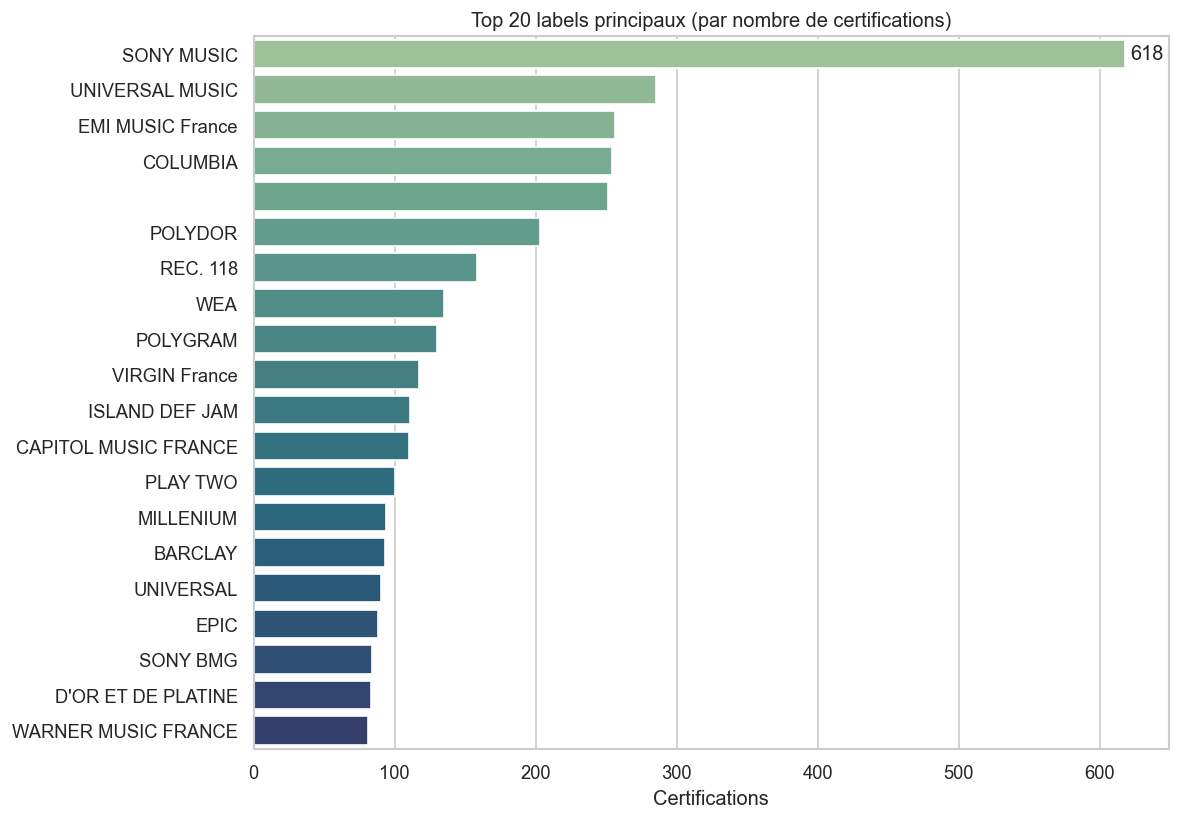

In [102]:
def extract_main_label(editeur_str):
    """Extrait le premier label mentionné dans la chaîne éditeur/distributeur."""
    if pd.isna(editeur_str):
        return 'Inconnu'
    return editeur_str.split('/')[0].strip()

df['Label principal'] = df['Editeur / Distributeur'].apply(extract_main_label)

top_labels = df['Label principal'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_labels.values, y=top_labels.index, ax=ax, palette='crest')
ax.bar_label(ax.containers[0], padding=3)
ax.set_title('Top 20 labels principaux (par nombre de certifications)')
ax.set_xlabel('Certifications')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../plots/top_labels.png')
plt.show()

## 8. Détection des collaborations

Les champs `Interprete` contiennent parfois plusieurs artistes séparés par `FEAT.`, `FEAT`, `&` ou `,`.  
Ces collaborations constituent la matière première du **graphe de co-artistes**.

In [103]:
import unicodedata

# --- 8.0 Normalisation des noms d'artistes ---
# Uniformise casse, accents et espaces avant tout traitement de graphe.
# Ex : 'MYLÈNE FARMER' / 'MYLENE FARMER' / 'Mylene Farmer' → 'MYLENE FARMER'

def normalize_interprete(s: str) -> str:
    """Majuscules, suppression des diacritiques, espaces normalisés."""
    if pd.isna(s):
        return s
    s = s.strip().upper()
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    return re.sub(r'\s+', ' ', s)

n_avant = df['Interprete'].nunique()
df['Interprete'] = df['Interprete'].apply(normalize_interprete)
n_apres = df['Interprete'].nunique()
print(f'Artistes uniques avant normalisation casse/accents : {n_avant}')
print(f'Artistes uniques après normalisation              : {n_apres}  (-{n_avant - n_apres} doublons résolus)')

# --- Auto-détection des duos/groupes avec '&' dans le nom ---
# Principe : si aucun des membres séparés par '&' n'existe en solo
# dans le dataset, l'entité est un duo/groupe → à ne PAS éclater.
# Ex : BIGFLO & OLI, DJADJA & DINAZ (ni BIGFLO, ni OLI, ni DJADJA, ni DINAZ en solo).
# Ex contre : ALAIN SOUCHON & LAURENT VOULZY → ALAIN SOUCHON existe en solo → collaboration.

all_interps = set(df['Interprete'].unique())

KNOWN_DUOS: set[str] = set()
for name in sorted(all_interps):
    if '&' not in name:
        continue
    if re.search(r'\sFEAT\.?\s|\sFT\.?\s', name, re.IGNORECASE):
        continue  # Entrées avec FEAT : pas des duos primaires
    parts = [p.strip() for p in name.split('&')]
    # Si aucun membre (>3 chars) n'existe seul → c'est un groupe/duo
    if not any(p in all_interps for p in parts if len(p) > 3):
        KNOWN_DUOS.add(name)

print(f'\nDuos/groupes auto-détectés ({len(KNOWN_DUOS)}) — préservés comme entités uniques :')
for d in sorted(KNOWN_DUOS):
    count = df['Interprete'].str.startswith(d, na=False).sum()
    print(f'  [{count:3d} certif.]  {d}')


Artistes uniques avant normalisation casse/accents : 3028
Artistes uniques après normalisation              : 2990  (-38 doublons résolus)

Duos/groupes auto-détectés (107) — préservés comme entités uniques :
  [  1 certif.]  ALAN WALKER, NOAH CYRUS & DIGITAL FARM ANIMALS
  [  1 certif.]  ALOK, MONDELLO’ G, CERES & TRIBBS
  [  2 certif.]  ANGUS & JULIA STONE
  [  1 certif.]  ANYME023 & SHAYDEE’S
  [  1 certif.]  AN’OM & VAYN
  [  1 certif.]  AYO & TEO
  [  1 certif.]  BECKY G & NATTI NATASHA
  [  1 certif.]  BELLO&DALLAS
  [ 17 certif.]  BIGFLO & OLI
  [  1 certif.]  BL3SS, CAMRINWATSIN & BBYCLOSE
  [  1 certif.]  BLACK EYED PEAS, OZUNA & J. REY SOUL
  [  1 certif.]  BOB & VANESSA
  [  1 certif.]  BUFFY & THE VAMPIRE
  [  1 certif.]  BURAK YETER & CECILIA KRULL
  [  4 certif.]  CABALLERO & JEANJASS
  [  1 certif.]  CAMELPHAT & ELDERBROOK
  [  1 certif.]  CARL ORFF & MICHEL PLASSON
  [  1 certif.]  CHARLES & EDDIE
  [  1 certif.]  CHARLIE & EDDIE
  [  1 certif.]  CHARLY & LULU
  [  1 ce

In [104]:
# Séparateurs : FEAT./FEAT (avec ou sans point), FT., &, virgule
COLLAB_PATTERN = re.compile(r'\s+FEAT\.?\s*|\s+FT\.?\s*', re.IGNORECASE)
AMP_PATTERN = re.compile(r'\s*&\s*')
COMMA_PATTERN = re.compile(r'\s*,\s*')


def split_artists(raw: str) -> list[str]:
    """Décompose une chaîne d'artistes en liste d'artistes individuels.

    Les duos/groupes présents dans KNOWN_DUOS (ex : BIGFLO & OLI,
    DJADJA & DINAZ) sont préservés comme entités uniques.
    Séparateurs reconnus : FEAT., FEAT, FT., &, virgule.
    """
    s = raw.strip()

    # 1. Protéger les duos connus — du plus long au plus court
    #    pour éviter qu'un sous-nom soit matché avant le nom complet.
    placeholders: dict[str, str] = {}
    s_cmp = s.upper()
    for i, duo in enumerate(sorted(KNOWN_DUOS, key=len, reverse=True)):
        idx = s_cmp.find(duo.upper())
        if idx >= 0:
            ph = f'__DUO{i}__'
            placeholders[ph] = s[idx:idx + len(duo)]
            s = s[:idx] + ph + s[idx + len(duo):]
            s_cmp = s.upper()

    # 2. Normaliser tous les séparateurs en '|'
    s = COLLAB_PATTERN.sub('|', s)
    s = AMP_PATTERN.sub('|', s)
    s = COMMA_PATTERN.sub('|', s)

    # 3. Découper et nettoyer
    parts = [p.strip() for p in s.split('|') if p.strip()]

    # 4. Restaurer les duos protégés
    result = []
    for p in parts:
        for ph, original in placeholders.items():
            p = p.replace(ph, original)
        if p:
            result.append(p)
    return result


df['Artists_list'] = df['Interprete'].apply(split_artists)
df['N_artistes'] = df['Artists_list'].apply(len)
df['Est_collab'] = df['N_artistes'] > 1

print(f"Entrées solo       : {(~df['Est_collab']).sum()}")
print(f"Entrées collab     : {df['Est_collab'].sum()}")
print(f"Taux collaboration : {df['Est_collab'].mean():.1%}")

# Vérification : les duos connus sont-ils bien préservés ?
print('\nVérification duos connus :')
for duo in sorted(KNOWN_DUOS)[:5]:
    sample = df[df['Interprete'].str.startswith(duo, na=False)]['Artists_list'].head(2).tolist()
    print(f'  {duo!r} → {sample}')


Entrées solo       : 7374
Entrées collab     : 929
Taux collaboration : 11.2%

Vérification duos connus :
  'ALAN WALKER, NOAH CYRUS & DIGITAL FARM ANIMALS' → [['ALAN WALKER, NOAH CYRUS & DIGITAL FARM ANIMALS']]
  'ALOK, MONDELLO’ G, CERES & TRIBBS' → [['ALOK, MONDELLO’ G, CERES & TRIBBS']]
  'ANGUS & JULIA STONE' → [['ANGUS & JULIA STONE'], ['ANGUS & JULIA STONE']]
  'ANYME023 & SHAYDEE’S' → [['ANYME023 & SHAYDEE’S']]
  'AN’OM & VAYN' → [['AN’OM & VAYN']]


/var/folders/84/zqd10b2n6jd17bm5tfw84l680000gn/T/ipykernel_2434/189034450.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_collab_artists.values, y=top_collab_artists.index,


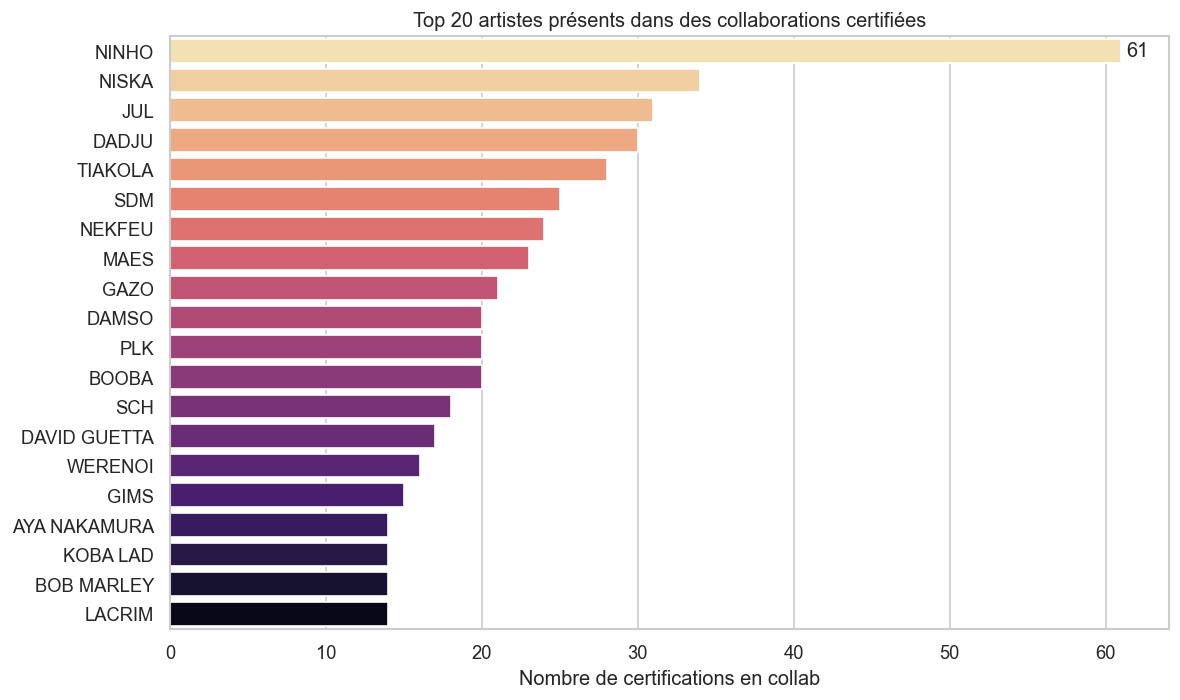

In [82]:
# Artistes les plus souvent en featuring
all_artists_in_collabs = [
    artist
    for artists in df[df['Est_collab']]['Artists_list']
    for artist in artists
]
top_collab_artists = pd.Series(Counter(all_artists_in_collabs)).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_collab_artists.values, y=top_collab_artists.index,
            ax=ax, palette='magma_r')
ax.bar_label(ax.containers[0], padding=3)
ax.set_title('Top 20 artistes présents dans des collaborations certifiées')
ax.set_xlabel('Nombre de certifications en collab')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../plots/top_collab_artists.png')
plt.show()

## 9. Construction préliminaire du graphe de co-artistes

On construit un graphe non orienté où :
- **Nœuds** = artistes uniques
- **Arêtes** = paires d'artistes ayant collaboré sur un titre certifié
- **Poids** = nombre de collaborations communes

In [83]:
from itertools import combinations

edge_counter: Counter = Counter()

for artists in df[df['Est_collab']]['Artists_list']:
    for a, b in combinations(sorted(set(artists)), 2):
        edge_counter[(a, b)] += 1

edges_df = (
    pd.DataFrame.from_records(
        [(a, b, w) for (a, b), w in edge_counter.items()],
        columns=['source', 'target', 'weight']
    )
    .sort_values('weight', ascending=False)
)

print(f'Arêtes totales (paires uniques) : {len(edges_df)}')
print(f'Nœuds distincts                 : {len(set(edges_df.source) | set(edges_df.target))}')
print('\nTop 10 collaborations :')
edges_df.head(10)

Arêtes totales (paires uniques) : 1272
Nœuds distincts                 : 834

Top 10 collaborations :


,source,target,weight
1028,BOB MARLEY,THE WAILERS,12
41,NINHO,NISKA,7
268,SLIMANE,VITAA,6
108,GAZO,TIAKOLA,6
665,LABRINTH,SIA,4
136,THE CREATOR,TYLER,4
278,ALPHA WANN,NEKFEU,4
463,JUL,SCH,4
45,DADJU,TAYC,4
138,KOBA LAD,NINHO,4


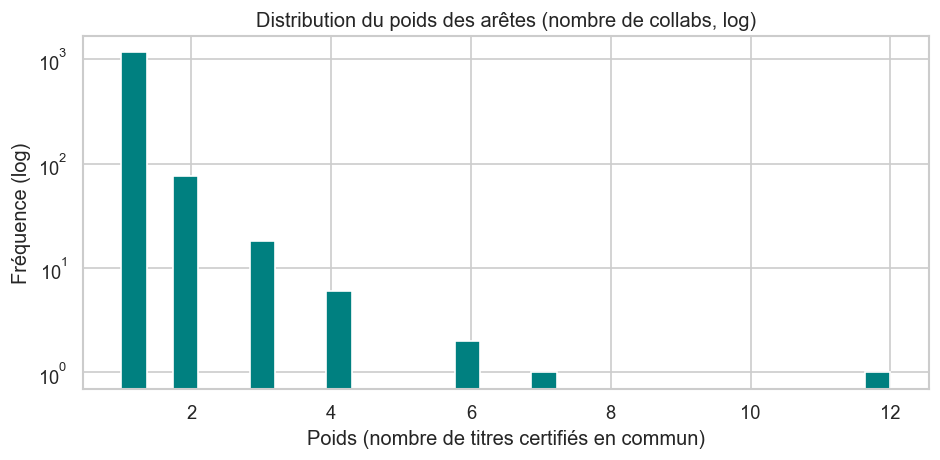

In [84]:
# Distribution du poids des arêtes
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(edges_df['weight'], bins=30, color='teal', edgecolor='white', log=True)
ax.set_title('Distribution du poids des arêtes (nombre de collabs, log)')
ax.set_xlabel('Poids (nombre de titres certifiés en commun)')
ax.set_ylabel('Fréquence (log)')
plt.tight_layout()
plt.savefig('../plots/edge_weight_distribution.png')
plt.show()

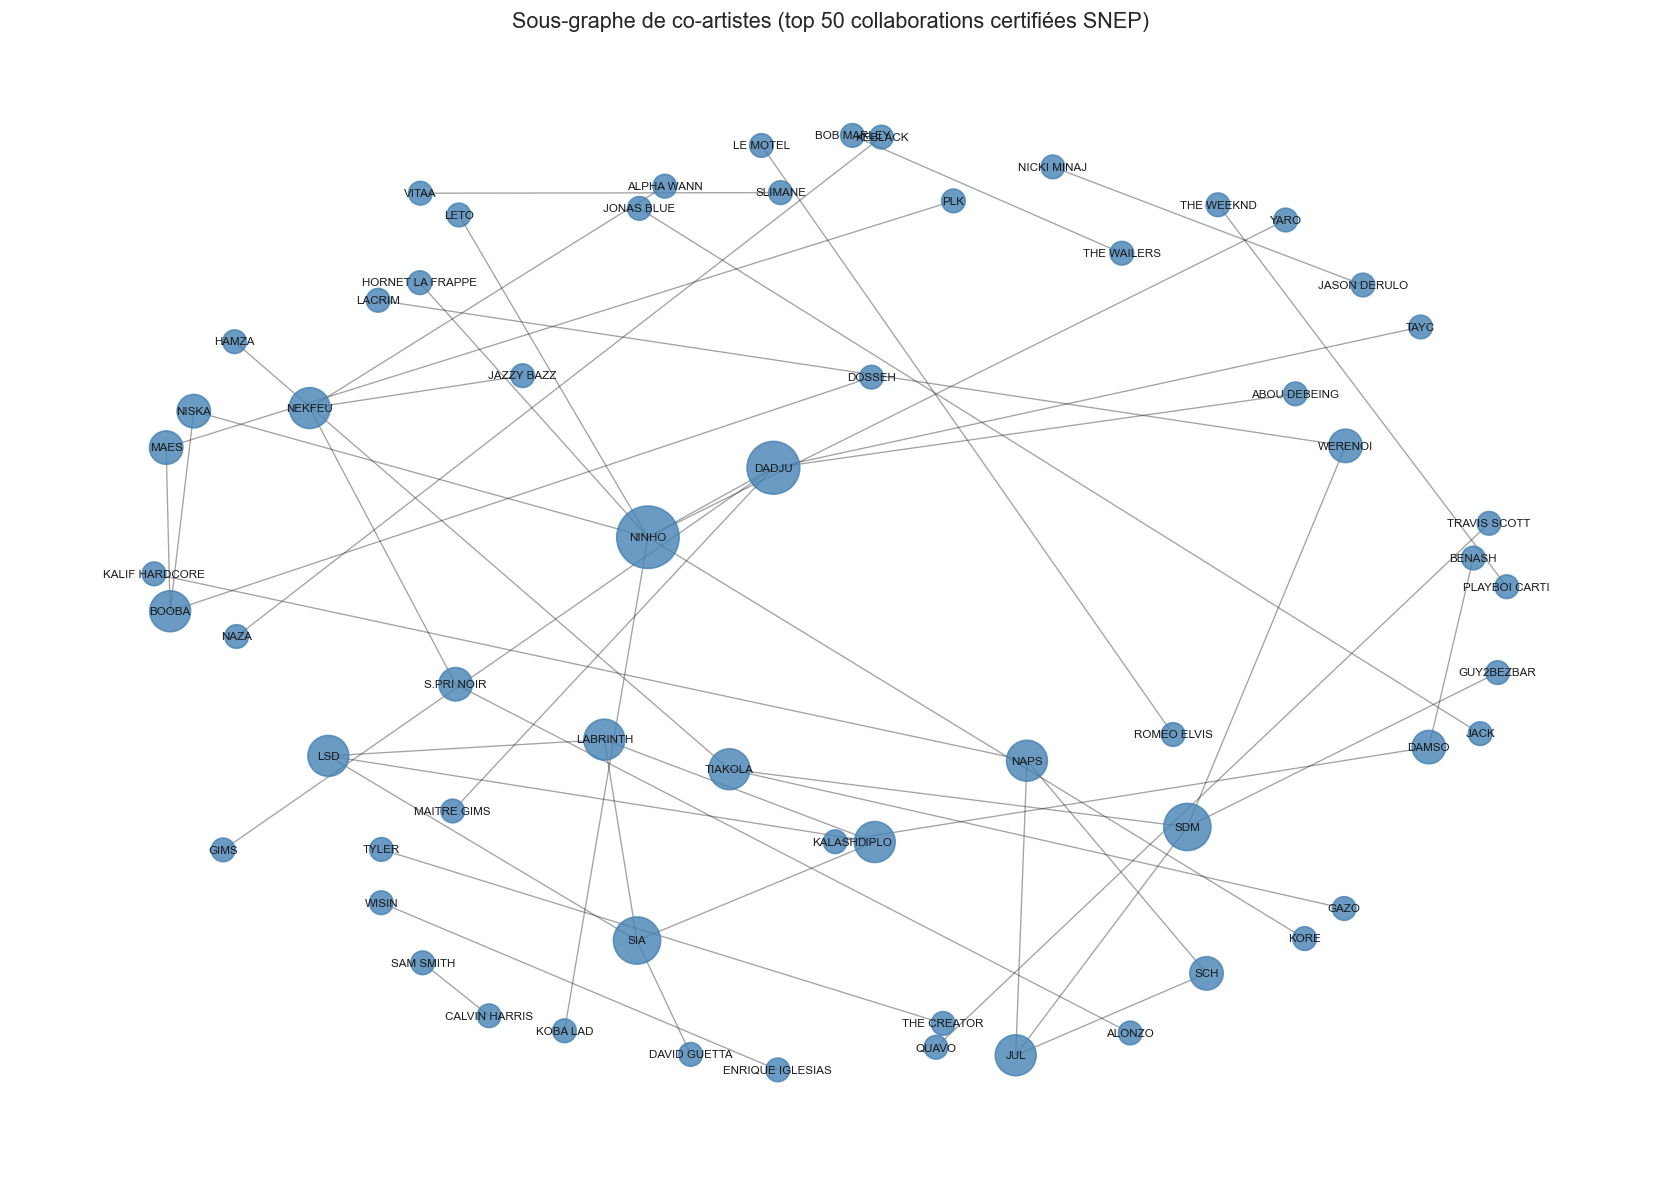

In [89]:
# Visualisation d'un sous-graphe (top 50 arêtes les plus lourdes)
try:
    import networkx as nx
    
    top_edges = edges_df.head(50)
    G_sub = nx.from_pandas_edgelist(top_edges, 'source', 'target', 'weight')
    
    degree = dict(G_sub.degree())
    node_sizes = [degree[n] * 200 for n in G_sub.nodes()]
    
    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(G_sub, seed=42, k=1.5)
    nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes,
                           node_color='steelblue', alpha=0.8, ax=ax)
    nx.draw_networkx_edges(G_sub, pos, alpha=0.4, width=0.8, ax=ax)
    nx.draw_networkx_labels(G_sub, pos, font_size=7, ax=ax)
    ax.set_title('Sous-graphe de co-artistes (top 50 collaborations certifiées SNEP)', fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('../plots/subgraph_top50.png')
    plt.show()
except ImportError:
    print("networkx non installé. Installer avec : pip install networkx")

## 10. Synthèse EDA

### Points clés

| Indicateur | Valeur |
|---|---|
| Certifications totales | 8 384 |
| Catégories principales | Singles (47%), Albums (45%), Vidéos (6%) |
| Niveau majoritaire | Or (57%) |
| Entries avec collaborations | ~1 078 (~13%) |
| Arêtes graphe (paires uniques) | voir cellule 9 |

### Prochaines étapes

1. **Nettoyage** : harmoniser les noms d'artistes (casse, accents, alias), normaliser les séparateurs de featuring
2. **Construction du graphe complet** avec `networkx` ou `igraph`
3. **Louvain** : détecter les communautés (`python-louvain` ou `leidenalg`)
4. **Évaluation** : modularité Q, silhouette score sur embeddings Node2Vec
5. **Recommandation** : étant donné un artiste, retourner les artistes de même communauté triés par centralité ou nombre de certifications